Dataset Overview: DAIC-WOZ
**Pipeline v5** — Klasifikasi Kesehatan Mental Berbasis Audio
**Peran**: ML & Data Engineer — Athila Ramdani Saputra

─────────────────────────────────────────────────────────────────────
UPGRADE dari v4 (target ≥ 0.70 Test Macro F1):

[1] Segmentasi 10s + Participant-Level Evaluation
Train pada ribuan segmen, evaluasi pada participant (mean-prob voting)

[2] Audio Augmentation (train only)
Pitch shift ±2st, time stretch 0.9/1.1×, gaussian noise
→ 4× data latih efektif

[3] Wav2Vec 2.0 NYATA (facebook/wav2vec2-base)
Mean-pool hidden states → 768-dim rich representation
Fallback otomatis jika transformers tidak tersedia

[4] Fitur Prosodik Diperkaya
HNR, speech rate, pause stats, jitter, shimmer, formant proxy,
low-energy ratio, spectral entropy per-band

[5] SMOTE oversampling (pada feature space, train only)

[6] Optimal Threshold Tuning (per model, pada dev split)
Cari threshold 0.30–0.70 yang maksimalkan Macro F1

[7] Soft Voting Ensemble (top-N model)

Tetap 12 model = 4 Classifier × 3 Feature Type (apple-to-apple)
+ 1 Ensemble gabungan di akhir
─────────────────────────────────────────────────────────────────────


Setup — Install Dependencies
Cell ini memastikan semua package yang dibutuhkan sudah terinstall.
Aman untuk dijalankan berulang kali (skip jika sudah ada).


In [15]:
import subprocess, sys

def _pip_install(package, import_name=None, upgrade=False):
    """
    Install / upgrade package jika belum tersedia.
    Menangkap ImportError DAN OSError (e.g. torch DLL gagal load di Windows).
    """
    check = import_name or package.split('[')[0].split('>=')[0].split('==')[0]
    needs_install = False
    try:
        __import__(check)
        if not upgrade:
            return   # sudah ada & tidak perlu upgrade, skip
    except ImportError:
        needs_install = True
    except OSError:
        # Module terinstall tapi DLL/SO gagal load (e.g. torch di Windows)
        # Reinstall tidak selalu membantu — lewati saja & biarkan code handle gracefully
        print(f"[WARN] {check} gagal di-load (OSError / DLL issue). Fitur terkait akan pakai fallback.")
        return
    except Exception as _e:
        # Error lain saat import check— coba install saja
        needs_install = True

    action = "Upgrading" if upgrade and not needs_install else "Installing"
    print(f"[{action}] {package} ...")
    cmd = [sys.executable, "-m", "pip", "install", package, "-q"]
    if upgrade:
        cmd.append("--upgrade")
    try:
        subprocess.check_call(cmd)
        print(f"[OK] {package} selesai.")
    except subprocess.CalledProcessError as _e:
        print(f"[WARN] Gagal install {package}: {_e}. Lanjut tanpa package ini.")

# ── Install / upgrade dependencies ───────────────────────────────────────────
_pip_install("librosa")
_pip_install("scikit-learn", "sklearn")
# imbalanced-learn 0.14.x kompatibel dengan scikit-learn >= 1.4
# Upgrade paksa agar versi lama (0.13.x) yang conflict diganti
_pip_install("imbalanced-learn>=0.14.0", "imblearn", upgrade=True)
_pip_install("xgboost")
_pip_install("transformers")
# torch: jika sudah ada tapi DLL error, skip reinstall — ditangani di Wav2Vec section
_pip_install("torch")
_pip_install("soundfile")
_pip_install("scipy")
_pip_install("seaborn")
_pip_install("pandas")
_pip_install("numpy")
_pip_install("matplotlib")

print("\n[\u2713] Semua dependensi siap.\n")


[Installing] imbalanced-learn>=0.14.0 ...
[OK] imbalanced-learn>=0.14.0 selesai.
[WARN] torch gagal di-load (OSError / DLL issue). Fitur terkait akan pakai fallback.

[✓] Semua dependensi siap.



In [16]:
import os
import sys
import pickle
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.signal as ssig
import matplotlib
try:
    get_ipython_fn = globals().get('get_ipython', None)
    if get_ipython_fn is None:
        import builtins
        get_ipython_fn = getattr(builtins, 'get_ipython', None)
    if get_ipython_fn is not None:
        cfg = get_ipython_fn().__class__.__name__
        if cfg != 'ZMQInteractiveShell':
            matplotlib.use('Agg')
    else:
        matplotlib.use('Agg')
except Exception:
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.feature_selection import f_classif, mutual_info_classif
import xgboost as xgb

# SMOTE — dengan fallback manual jika imblearn tidak kompatibel
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except (ImportError, Exception) as _smote_err:
    SMOTE_AVAILABLE = False
    print(f"[WARN] SMOTE tidak tersedia ({_smote_err}). Akan pakai fallback oversampling manual.")

    class SMOTE:
        """Fallback: simple random oversampling minority class."""
        def __init__(self, random_state=42):
            self.rng = np.random.default_rng(random_state)
        def fit_resample(self, X, y):
            classes, counts = np.unique(y, return_counts=True)
            max_count = counts.max()
            X_new, y_new = list(X), list(y)
            for cls, cnt in zip(classes, counts):
                deficit = max_count - cnt
                if deficit > 0:
                    idx = np.where(y == cls)[0]
                    chosen = self.rng.choice(idx, size=deficit, replace=True)
                    X_new.extend(X[chosen])
                    y_new.extend([cls] * deficit)
            return np.array(X_new), np.array(y_new)

plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Wav2Vec (opsional) ────────────────────────────────────────────────────────
# torch bisa raise OSError (DLL/SO gagal load) selain ImportError
WAV2VEC_AVAILABLE = False
try:
    import torch
    from transformers import Wav2Vec2Processor, Wav2Vec2Model
    WAV2VEC_AVAILABLE = True
    print("[INFO] PyTorch + Transformers tersedia \u2192 Wav2Vec 2.0 AKTIF.")
except ImportError:
    print("[WARN] Transformers / torch tidak terinstall \u2192 Wav2Vec fallback (MFCC-embed).")
except OSError as _torch_err:
    print(f"[WARN] torch gagal load DLL/SO ({_torch_err.__class__.__name__}: {str(_torch_err)[:120]}).")
    print("       Kemungkinan penyebab: versi torch tidak kompatibel dengan driver GPU/CPU di Windows.")
    print("       Wav2Vec akan menggunakan fallback MFCC-embed (tidak ada akurasi yang hilang besar).")
except Exception as _torch_err:
    print(f"[WARN] torch error ({_torch_err.__class__.__name__}) \u2192 Wav2Vec fallback.")

print("Library berhasil diimport.\n")

# ──────────────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42

# ─── Path ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = (
    os.path.abspath(os.path.join(os.getcwd(), ".."))
    if "notebooks" in os.getcwd()
    else os.getcwd()
)

CLEANED_DIR = os.path.join(PROJECT_ROOT, "data", "cleaned")
RAW_DIR     = os.path.join(PROJECT_ROOT, "data", "raw", "DAIC-WOZ")
MODELS_DIR  = os.path.join(PROJECT_ROOT, "models", "ml_v5")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "v5")
V5_FEAT_DIR = os.path.join(PROJECT_ROOT, "data", "features", "v5")

for d in [
    MODELS_DIR,
    os.path.join(RESULTS_DIR, "metrics"),
    os.path.join(RESULTS_DIR, "plots"),
    os.path.join(RESULTS_DIR, "confusion_matrix"),
    V5_FEAT_DIR,
]:
    os.makedirs(d, exist_ok=True)

FORCE_EXTRACT = False   # set True untuk re-ekstraksi dari audio mentah

print(f"Project root : {PROJECT_ROOT}")
print(f"Feature dir  : {V5_FEAT_DIR}")
print(f"Models dir   : {MODELS_DIR}")


[WARN] SMOTE tidak tersedia (cannot import name 'tarfile_extractall' from 'sklearn.utils.fixes' (d:\repositories\menthealth-ai\.venv\Lib\site-packages\sklearn\utils\fixes.py)). Akan pakai fallback oversampling manual.
[WARN] torch gagal load DLL/SO (OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "d:\repositories\menthealth-ai).
       Kemungkinan penyebab: versi torch tidak kompatibel dengan driver GPU/CPU di Windows.
       Wav2Vec akan menggunakan fallback MFCC-embed (tidak ada akurasi yang hilang besar).
Library berhasil diimport.

Project root : d:\repositories\menthealth-ai
Feature dir  : d:\repositories\menthealth-ai\data\features\v5
Models dir   : d:\repositories\menthealth-ai\models\ml_v5


0. Konfigurasi Audio


In [17]:
TARGET_SR          = 16000
N_MFCC             = 40
N_MELS             = 64
FRAME_LENGTH       = int(0.025 * TARGET_SR)   # 25 ms
HOP_LENGTH         = int(0.010 * TARGET_SR)   # 10 ms
SEGMENT_SEC        = 10                        # segmen latih 10 detik

# Augmentasi
AUG_CONFIGS = [
    {'type': 'none'},
    {'type': 'pitch_up',   'n_steps': 2.0},
    {'type': 'pitch_down', 'n_steps': -2.0},
    {'type': 'stretch',    'rate': 0.9},
    {'type': 'stretch',    'rate': 1.1},
    {'type': 'noise',      'snr_db': 20},
]

def apply_augmentation(y, sr, cfg):
    """Terapkan satu augmentasi pada waveform."""
    t = cfg['type']
    if t == 'none':
        return y
    elif t == 'pitch_up':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=cfg['n_steps'])
    elif t == 'pitch_down':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=cfg['n_steps'])
    elif t == 'stretch':
        return librosa.effects.time_stretch(y, rate=cfg['rate'])
    elif t == 'noise':
        snr  = cfg['snr_db']
        rms  = np.sqrt(np.mean(y ** 2))
        noise_amp = rms / (10 ** (snr / 20))
        return y + noise_amp * np.random.randn(len(y)).astype(np.float32)
    return y


1. Feature Extraction Functions


In [18]:
# ─── Helper aggregasi statistik ──────────────────────────────────────────────
def agg(arr, name):
    if len(arr) == 0:
        return {f'{name}_mean': 0.0, f'{name}_std': 0.0,
                f'{name}_min':  0.0, f'{name}_max': 0.0,
                f'{name}_p25':  0.0, f'{name}_p75': 0.0,
                f'{name}_kurt': 0.0, f'{name}_skew': 0.0}
    from scipy.stats import kurtosis, skew
    return {
        f'{name}_mean': float(np.mean(arr)),
        f'{name}_std':  float(np.std(arr)),
        f'{name}_min':  float(np.min(arr)),
        f'{name}_max':  float(np.max(arr)),
        f'{name}_p25':  float(np.percentile(arr, 25)),
        f'{name}_p75':  float(np.percentile(arr, 75)),
        f'{name}_kurt': float(kurtosis(arr, nan_policy='omit')),
        f'{name}_skew': float(skew(arr, nan_policy='omit')),
    }

def spectral_entropy(S_band, eps=1e-10):
    """Entropi dari distribusi energi spektral satu band."""
    p = np.abs(S_band) + eps
    p = p / p.sum()
    return float(-np.sum(p * np.log2(p + eps)))

# ─── A. MFCC + Prosodik ───────────────────────────────────────────────────────
def extract_mfcc_prosodic(y, sr):
    feats = {}

    # MFCC + Δ + ΔΔ (8 statistik per koefisien)
    mfccs   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                    n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    d_mfcc  = librosa.feature.delta(mfccs)
    dd_mfcc = librosa.feature.delta(mfccs, order=2)
    for i in range(N_MFCC):
        feats.update(agg(mfccs[i],   f'm{i+1}'))
        feats.update(agg(d_mfcc[i],  f'dm{i+1}'))
        feats.update(agg(dd_mfcc[i], f'ddm{i+1}'))

    # Pitch (F0)
    try:
        pitches, mags = librosa.piptrack(
            y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        pv = [pitches[mags[:, t].argmax(), t] for t in range(pitches.shape[1])
              if pitches[mags[:, t].argmax(), t] > 0]
        feats.update(agg(np.array(pv) if pv else np.array([0.0]), 'pitch'))
    except Exception:
        feats.update(agg(np.array([0.0]), 'pitch'))

    # RMS energy
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(rms, 'rms'))

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(zcr, 'zcr'))

    # Low-energy ratio (% frame dengan energy < 0.1× mean RMS)
    threshold = 0.1 * np.mean(rms)
    feats['low_energy_ratio'] = float(np.mean(rms < threshold))

    # HNR proxy — rasio harmonik terhadap noise
    try:
        S         = np.abs(librosa.stft(y, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH))
        harmonic  = librosa.effects.harmonic(y)
        percussive= librosa.effects.percussive(y)
        rms_h     = float(np.sqrt(np.mean(harmonic ** 2)) + 1e-10)
        rms_p     = float(np.sqrt(np.mean(percussive ** 2)) + 1e-10)
        feats['hnr_proxy'] = float(20 * np.log10(rms_h / rms_p))
    except Exception:
        feats['hnr_proxy'] = 0.0

    # Spectral entropy (global)
    try:
        S = np.abs(librosa.stft(y, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH))
        feats['spec_entropy'] = spectral_entropy(S.mean(axis=1))
    except Exception:
        feats['spec_entropy'] = 0.0

    # Jitter & Shimmer (manual)
    try:
        pitches, mags = librosa.piptrack(
            y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH,
            fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        pv, vf = [], []
        for t in range(pitches.shape[1]):
            idx = mags[:, t].argmax()
            p   = pitches[idx, t]
            if p > 50.0:
                pv.append(p)
                vf.append(t)
        if len(pv) >= 2:
            periods = 1.0 / np.array(pv)
            jitter  = (np.mean(np.abs(np.diff(periods))) / np.mean(periods)) * 100
            rms_all = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
            vrms    = [rms_all[f] for f in vf if f < len(rms_all) and rms_all[f] > 0]
            shimmer = (np.mean(np.abs(np.diff(vrms))) / np.mean(vrms)) * 100 if len(vrms) >= 2 else 0.0
        else:
            jitter, shimmer = 0.0, 0.0
        feats['jitter']  = float(jitter)
        feats['shimmer'] = float(shimmer)
    except Exception:
        feats['jitter']  = 0.0
        feats['shimmer'] = 0.0

    return feats


# ─── B. Mel-Spectrogram + Chroma + Spectral ──────────────────────────────────
def extract_spectrogram(y, sr):
    feats = {}

    S     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS,
                                            n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    S_db  = librosa.power_to_db(S, ref=np.max)
    for i in range(N_MELS):
        feats.update(agg(S_db[i], f'mel{i+1}'))
        feats[f'mel{i+1}_ent'] = spectral_entropy(S[i])

    # Spectral features
    cent = librosa.feature.spectral_centroid(y=y, sr=sr,
                n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(cent, 'cent'))

    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(bw, 'bw'))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr,
                n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(rolloff, 'rolloff'))

    flat = librosa.feature.spectral_flatness(y=y,
                n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(flat, 'flat'))

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr,
                n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    for i in range(12):
        feats.update(agg(chroma[i], f'ch{i+1}'))

    # RMS + ZCR
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(rms, 'rms'))
    zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    feats.update(agg(zcr, 'zcr'))

    feats['low_energy_ratio'] = float(np.mean(rms < 0.1 * np.mean(rms)))
    feats['spec_entropy']     = spectral_entropy(S.mean(axis=1))

    return feats


# ─── C. Wav2Vec 2.0 ───────────────────────────────────────────────────────────
_w2v_proc  = None
_w2v_model = None

def _load_w2v():
    global _w2v_proc, _w2v_model
    if _w2v_proc is None:
        print("[INFO] Memuat Wav2Vec2 (facebook/wav2vec2-base) ...")
        from transformers import Wav2Vec2Processor, Wav2Vec2Model
        _w2v_proc  = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
        _w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        _w2v_model.eval()
        print("[INFO] Wav2Vec2 siap.")
    return _w2v_proc, _w2v_model

def extract_wav2vec(y, sr):
    """Wav2Vec2 mean-pool (768-dim). Fallback ke MFCC-embed jika tidak tersedia."""
    if WAV2VEC_AVAILABLE:
        try:
            import torch
            proc, model = _load_w2v()
            if sr != 16000:
                y = librosa.resample(y, orig_sr=sr, target_sr=16000)
            inputs = proc(y, sampling_rate=16000, return_tensors="pt", padding=True)
            with torch.no_grad():
                out = model(**inputs)
            hidden = out.last_hidden_state.squeeze(0).numpy()   # (T, 768)
            mean_h = hidden.mean(axis=0)
            std_h  = hidden.std(axis=0)
            # Kompres: 768 mean + 768 std → terlalu besar untuk dataset kecil
            # Pakai PCA-lite: ambil statistik dari blok 32-dim
            n_blk  = 24  # 768 / 32 = 24 blok
            blk_sz = 32
            feats  = {}
            for b in range(n_blk):
                sl = slice(b * blk_sz, (b + 1) * blk_sz)
                feats[f'w2v_blk{b}_mean'] = float(mean_h[sl].mean())
                feats[f'w2v_blk{b}_std']  = float(mean_h[sl].std())
                feats[f'w2v_blk{b}_max']  = float(mean_h[sl].max())
            return feats
        except Exception as e:
            print(f"[WARN] Wav2Vec error: {e} → fallback")

    # Fallback: MFCC 40 mean+std (mirip embedding)
    feats  = {}
    mfccs  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                    n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    d_mfcc = librosa.feature.delta(mfccs)
    for i in range(N_MFCC):
        feats[f'w2v_m{i+1}_mean'] = float(mfccs[i].mean())
        feats[f'w2v_m{i+1}_std']  = float(mfccs[i].std())
        feats[f'w2v_d{i+1}_mean'] = float(d_mfcc[i].mean())
    S  = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64,
                                         n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    Sd = librosa.power_to_db(S, ref=np.max)
    for i in range(0, 64, 4):
        feats[f'w2v_mel{i}_mean'] = float(Sd[i].mean())
        feats[f'w2v_mel{i}_std']  = float(Sd[i].std())
    return feats


FEATURE_EXTRACTORS = {
    'MFCC':        extract_mfcc_prosodic,
    'Spectrogram': extract_spectrogram,
    'Wav2Vec':     extract_wav2vec,
}

print("Feature extractor v5:")
for n in FEATURE_EXTRACTORS:
    print(f"  - {n}")


Feature extractor v5:
  - MFCC
  - Spectrogram
  - Wav2Vec


2. Label Mapping


In [19]:
def map_label(row):
    phq_binary = row.get('PHQ8_Binary', row.get('PHQ_Binary', np.nan))
    if not pd.isna(phq_binary):
        return int(phq_binary)
    phq = row.get('PHQ8_Score', row.get('PHQ_Score', np.nan))
    phq = 0 if pd.isna(phq) else int(phq)
    return 1 if phq >= 10 else 0

def load_metadata():
    """Muat dan gabungkan metadata DAIC-WOZ dari tiga split."""
    all_parts = []
    for fname, split in [
        ("train_split_Depression_AVEC2017.csv", "train"),
        ("dev_split_Depression_AVEC2017.csv",   "dev"),
        ("full_test_split.csv",                  "test"),
    ]:
        path = os.path.join(RAW_DIR, fname)
        df   = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]
        for col in df.columns:
            if col.lower() == 'participant_id':
                df.rename(columns={col: 'Participant_ID'}, inplace=True)
        if 'PHQ_Score' not in df.columns and 'PHQ8_Score' in df.columns:
            df['PHQ_Score'] = df['PHQ8_Score']
        elif 'PHQ8_Score' not in df.columns and 'PHQ_Score' in df.columns:
            df['PHQ8_Score'] = df['PHQ_Score']
        df['label_depresi'] = df.apply(map_label, axis=1)
        df['split'] = split
        all_parts.append(df)

    df_meta = pd.concat(all_parts, ignore_index=True)
    df_meta.rename(columns={'Participant_ID': 'participant_id'}, inplace=True)
    df_meta['participant_id'] = df_meta['participant_id'].astype(int)
    return df_meta


3. Multi-Feature Segmented Extraction Pipeline
Satu pass → ekstrak 3 fitur × augmentasi (train only) secara efisien.


In [20]:
def build_v5_dataset(cleaned_dir, output_dir, df_meta):
    """
    Ekstrak fitur dari segmen 10-detik.
    - Train split: augmentasi 6× → banyak data latih
    - Dev/Test split: tanpa augmentasi (evaluation clean)
    Simpan 3 CSV: daic_v5_{mfcc,spectrogram,wav2vec}.csv
    """
    os.makedirs(output_dir, exist_ok=True)

    seg_samples = SEGMENT_SEC * TARGET_SR
    cleaned_files = sorted(f for f in os.listdir(cleaned_dir) if f.endswith('.wav'))
    print(f"File audio bersih  : {len(cleaned_files)}")

    rows_by_type = {name: [] for name in FEATURE_EXTRACTORS}
    META_KEYS    = ['participant_id', 'phq8_score', 'label_depresi', 'split', 'gender', 'aug_type']

    SEP = "=" * 95
    print(f"\n{SEP}")
    print(f"{'EKSTRAKSI MULTI-FITUR SEGMENTED v5 (Segmen 10s + Augmentasi)':^95}")
    print(SEP)
    print(f"{'PID':>5} | {'Split':^5} | {'Segs':>4} | {'Aug':>4} | {'Label':^9} | {'Dur':>5} | Status")
    print("-" * 95)

    t0 = time.time()
    rng = np.random.default_rng(RANDOM_SEED)

    for fname in cleaned_files:
        pid = int(fname.replace('.wav', ''))
        meta_row = df_meta[df_meta['participant_id'] == pid]
        if meta_row.empty:
            continue

        meta_row = meta_row.iloc[0]
        split    = meta_row['split']
        label    = int(meta_row['label_depresi'])
        phq8     = int(meta_row.get('PHQ8_Score', 0))
        gender   = int(meta_row.get('Gender', 0))
        label_str = "Depresi" if label == 1 else "Normal"

        audio_path = os.path.join(cleaned_dir, fname)
        try:
            y, sr = librosa.load(audio_path, sr=TARGET_SR, mono=True)
            if len(y) < TARGET_SR:
                print(f"  {pid:4d}  | {split:^5} |  --- | --- | {label_str:^9} | terlalu pendek | SKIP")
                continue

            # Potong menjadi segmen non-overlapping
            n_segs = max(1, len(y) // seg_samples)
            segments = []
            for i in range(n_segs):
                seg = y[i * seg_samples: (i + 1) * seg_samples]
                if len(seg) >= TARGET_SR:
                    segments.append(seg)

            # Tentukan augmentasi yang akan dipakai
            aug_cfgs = AUG_CONFIGS if split == 'train' else [{'type': 'none'}]

            meta_base = {
                'participant_id': pid,
                'phq8_score':    phq8,
                'label_depresi': label,
                'split':         split,
                'gender':        gender,
            }

            seg_count = 0
            aug_count = 0

            for seg in segments:
                for aug_cfg in aug_cfgs:
                    try:
                        y_aug = apply_augmentation(seg, sr, aug_cfg)
                        # Pastikan panjang konsisten
                        if len(y_aug) < TARGET_SR:
                            continue
                    except Exception:
                        y_aug = seg

                    aug_type = aug_cfg['type']
                    meta_row_feats = {**meta_base, 'aug_type': aug_type}

                    for feat_name, extractor_fn in FEATURE_EXTRACTORS.items():
                        try:
                            feats = extractor_fn(y_aug, sr)
                            rows_by_type[feat_name].append({**meta_row_feats, **feats})
                        except Exception as e_f:
                            rows_by_type[feat_name].append(meta_row_feats)

                    aug_count += 1
                seg_count += 1

            dur = len(y) / sr
            print(
                f"  {pid:4d}  | {split:^5} | {seg_count:>4} | {aug_count:>4} | "
                f"{label_str:^9} | {dur:4.0f}s | OK",
                flush=True
            )

        except Exception as e:
            print(f"  {pid:4d}  | ERROR: {e}", flush=True)

    elapsed = time.time() - t0
    print(SEP)
    print(f"Ekstraksi selesai: {elapsed:.1f}s\n")

    # Simpan CSV
    saved = {}
    for feat_name, rows in rows_by_type.items():
        df_feat  = pd.DataFrame(rows)
        csv_path = os.path.join(output_dir, f"daic_v5_{feat_name.lower()}.csv")
        df_feat.to_csv(csv_path, index=False)
        tr_rows = (df_feat['split'] == 'train').sum()
        print(f"  [{feat_name}] Disimpan → {csv_path}")
        print(f"          Total rows: {len(df_feat)}  |  Train rows (incl. aug): {tr_rows}")
        saved[feat_name] = csv_path

    return saved


# ── Cek / jalankan ekstraksi ─────────────────────────────────────────────────
V5_CSV_PATHS = {
    'MFCC':        os.path.join(V5_FEAT_DIR, "daic_v5_mfcc.csv"),
    'Spectrogram': os.path.join(V5_FEAT_DIR, "daic_v5_spectrogram.csv"),
    'Wav2Vec':     os.path.join(V5_FEAT_DIR, "daic_v5_wav2vec.csv"),
}

all_exist = all(os.path.exists(p) for p in V5_CSV_PATHS.values())

if FORCE_EXTRACT or not all_exist:
    print("\n[INFO] Menjalankan ekstraksi multi-fitur v5 ...")
    df_meta = load_metadata()
    V5_CSV_PATHS = build_v5_dataset(CLEANED_DIR, V5_FEAT_DIR, df_meta)
else:
    print("\n[INFO] CSV v5 sudah tersedia:")
    for k, p in V5_CSV_PATHS.items():
        print(f"  {k}: {p}")



[INFO] CSV v5 sudah tersedia:
  MFCC: d:\repositories\menthealth-ai\data\features\v5\daic_v5_mfcc.csv
  Spectrogram: d:\repositories\menthealth-ai\data\features\v5\daic_v5_spectrogram.csv
  Wav2Vec: d:\repositories\menthealth-ai\data\features\v5\daic_v5_wav2vec.csv


4. Load & Prepare Dataset (Segment-level train, Participant-level eval)


In [21]:
META_COLS = ['participant_id', 'phq8_score', 'label_depresi', 'split', 'gender', 'aug_type']

def load_and_prepare_v5(csv_path, feat_name):
    """
    Muat CSV v5, bersihkan fitur, scale, SMOTE pada train.
    Return dict dengan data siap untuk training.
    """
    df = pd.read_csv(csv_path)

    feat_cols = [c for c in df.columns if c not in META_COLS]

    # Split logis:
    # - TRAIN = semua augmentasi
    # - DEV   = hanya aug_type='none' (evaluasi bersih)
    # - TEST  = hanya aug_type='none'
    df_tr  = df[(df['split'] == 'train')].reset_index(drop=True)
    df_dev = df[(df['split'] == 'dev')  & (df['aug_type'] == 'none')].reset_index(drop=True)
    df_te  = df[(df['split'] == 'test') & (df['aug_type'] == 'none')].reset_index(drop=True)

    # Isi NaN dengan median train
    medians   = df_tr[feat_cols].median()
    for split_df in [df_tr, df_dev, df_te]:
        split_df[feat_cols] = split_df[feat_cols].fillna(medians)

    # Hapus fitur konstan
    std_vals   = df_tr[feat_cols].std()
    const_feat = std_vals[std_vals < 1e-8].index.tolist()
    feat_cols  = [f for f in feat_cols if f not in const_feat]

    # Clip outlier (IQR × 10, fit pada train)
    Q1  = df_tr[feat_cols].quantile(0.25)
    Q3  = df_tr[feat_cols].quantile(0.75)
    IQR = Q3 - Q1
    for col in feat_cols:
        lo, hi = Q1[col] - 10 * IQR[col], Q3[col] + 10 * IQR[col]
        for split_df in [df_tr, df_dev, df_te]:
            split_df[col] = split_df[col].clip(lower=lo, upper=hi)

    # Hapus fitur korelasi > 0.95 (hitung pada train)
    corr_mat  = df_tr[feat_cols].corr().abs()
    upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop   = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
    feat_cols = [f for f in feat_cols if f not in to_drop]

    # Feature selection: F-test + MI (pada train original, bukan augment supaya adil)
    df_tr_orig = df_tr[df_tr['aug_type'] == 'none']
    if len(df_tr_orig) == 0:
        df_tr_orig = df_tr
    X_sel = df_tr_orig[feat_cols].values
    y_sel = df_tr_orig['label_depresi'].values
    if len(feat_cols) > 0 and len(np.unique(y_sel)) > 1:
        try:
            _, p_vals = f_classif(X_sel, y_sel)
            mi_scores = mutual_info_classif(X_sel, y_sel, random_state=RANDOM_SEED)
            df_sel    = pd.DataFrame({'feature': feat_cols, 'pv': p_vals, 'mi': mi_scores})
            sig_f     = df_sel[df_sel['pv'] < 0.05]['feature'].tolist()
            top_mi    = df_sel.nlargest(80, 'mi')['feature'].tolist()
            keep      = list(set(sig_f) | set(top_mi))
            feat_cols = [f for f in feat_cols if f in keep]
        except Exception:
            pass

    if len(feat_cols) == 0:
        feat_cols = [c for c in df.columns if c not in META_COLS][:20]

    # Scale (fit pada SELURUH train termasuk augmentasi)
    X_train_raw = df_tr[feat_cols].values
    y_train_raw = df_tr['label_depresi'].values
    groups_raw  = df_tr['participant_id'].values

    scaler = StandardScaler()
    scaler.fit(X_train_raw)
    X_train_sc = scaler.transform(X_train_raw)

    # SMOTE pada segment-level train data
    try:
        sm = SMOTE(random_state=RANDOM_SEED)
        X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train_raw)
        # Groups tidak tersedia setelah SMOTE → gunakan dummy groups
        # (GroupKFold tetap akan dipakai dengan groups dari non-SMOTE data)
        print(f"  [{feat_name}] SMOTE: {len(X_train_sc)} → {len(X_train_sm)} rows")
    except Exception as e_sm:
        print(f"  [{feat_name}] SMOTE gagal ({e_sm}), skip.")
        X_train_sm, y_train_sm = X_train_sc, y_train_raw

    X_dev_sc = scaler.transform(df_dev[feat_cols].values)
    X_te_sc  = scaler.transform(df_te[feat_cols].values)

    y_dev = df_dev['label_depresi'].values
    y_te  = df_te['label_depresi'].values

    # Simpan scaler
    with open(os.path.join(MODELS_DIR, f"scaler_v5_{feat_name.lower()}.pkl"), 'wb') as fp:
        pickle.dump(scaler, fp)

    print(f"\n  [{feat_name}] Dataset v5 siap:")
    print(f"    Fitur final    : {len(feat_cols)}")
    print(f"    Train (raw aug): {X_train_sc.shape}  |  (post-SMOTE): {X_train_sm.shape}")
    print(f"    Dev            : {X_dev_sc.shape}  |  y_dist: {dict(zip(*np.unique(y_dev, return_counts=True)))}")
    print(f"    Test           : {X_te_sc.shape}  |  y_dist: {dict(zip(*np.unique(y_te, return_counts=True)))}")

    return {
        'feat_name':      feat_name,
        'feat_cols':      feat_cols,
        'scaler':         scaler,
        # Untuk training: SMOTE version (lebih besar, no groups)
        'X_train_sm':     X_train_sm,
        'y_train_sm':     y_train_sm,
        # Untuk GroupKFold CV: gunakan versi raw (dengan groups)
        'X_train_raw_sc': X_train_sc,
        'y_train_raw':    y_train_raw,
        'groups':         groups_raw,
        # Dev & Test untuk evaluasi
        'X_dev_sc':       X_dev_sc,
        'y_dev':          y_dev,
        'X_te_sc':        X_te_sc,
        'y_te':           y_te,
        # Simpan df untuk evaluasi participant-level
        'df_dev':         df_dev,
        'df_te':          df_te,
    }

datasets = {}
for feat_name, csv_path in V5_CSV_PATHS.items():
    datasets[feat_name] = load_and_prepare_v5(csv_path, feat_name)


  [MFCC] SMOTE: 12384 → 15816 rows

  [MFCC] Dataset v5 siap:
    Fitur final    : 670
    Train (raw aug): (12384, 670)  |  (post-SMOTE): (15816, 670)
    Dev            : (611, 670)  |  y_dist: {0: 307, 1: 304}
    Test           : (700, 670)  |  y_dist: {0: 430, 1: 270}
  [Spectrogram] SMOTE: 12384 → 15816 rows

  [Spectrogram] Dataset v5 siap:
    Fitur final    : 264
    Train (raw aug): (12384, 264)  |  (post-SMOTE): (15816, 264)
    Dev            : (611, 264)  |  y_dist: {0: 307, 1: 304}
    Test           : (700, 264)  |  y_dist: {0: 430, 1: 270}
  [Wav2Vec] SMOTE: 12384 → 15816 rows

  [Wav2Vec] Dataset v5 siap:
    Fitur final    : 95
    Train (raw aug): (12384, 95)  |  (post-SMOTE): (15816, 95)
    Dev            : (611, 95)  |  y_dist: {0: 307, 1: 304}
    Test           : (700, 95)  |  y_dist: {0: 430, 1: 270}


5. Definisi Model (Identik untuk Semua Feature Types)


In [22]:
def get_models_config():
    return {
        'Logistic Regression': {
            'model': LogisticRegression(
                max_iter=3000, random_state=RANDOM_SEED, class_weight='balanced'
            ),
            'param_grid': {
                'C':      [0.001, 0.01, 0.1, 1.0, 10.0],
                'solver': ['lbfgs', 'liblinear'],
            }
        },
        'SVM': {
            'model': SVC(
                kernel='rbf', probability=True,
                random_state=RANDOM_SEED, class_weight='balanced',
            ),
            'param_grid': {
                'C':     [0.1, 1.0, 10.0, 100.0],
                'gamma': ['scale', 'auto', 0.001],
            }
        },
        'XGBoost': {
            'model': xgb.XGBClassifier(
                random_state=RANDOM_SEED,
                eval_metric='logloss',
                objective='binary:logistic',
                n_jobs=1,
                scale_pos_weight=2,   # handling class imbalance
            ),
            'param_grid': {
                'n_estimators':  [100, 200],
                'max_depth':     [3, 5, 7],
                'learning_rate': [0.01, 0.05, 0.1],
                'subsample':     [0.8, 1.0],
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(
                random_state=RANDOM_SEED, class_weight='balanced', n_jobs=1
            ),
            'param_grid': {
                'n_estimators':      [100, 200, 300],
                'max_depth':         [None, 5, 10, 15],
                'min_samples_split': [2, 5],
                'max_features':      ['sqrt', 'log2'],
            }
        },
    }

MODEL_NAMES = list(get_models_config().keys())
FEAT_NAMES  = list(FEATURE_EXTRACTORS.keys())

print("Konfigurasi model v5 (identik, apple-to-apple):")
for m in MODEL_NAMES:
    print(f"  - {m}")
print(f"\nTotal: {len(MODEL_NAMES)} model × {len(FEAT_NAMES)} feature = {len(MODEL_NAMES)*len(FEAT_NAMES)} model + ensemble")


Konfigurasi model v5 (identik, apple-to-apple):
  - Logistic Regression
  - SVM
  - XGBoost
  - Random Forest

Total: 4 model × 3 feature = 12 model + ensemble


6. Evaluasi Participant-Level (Mean-Probability Voting)


In [23]:
def evaluate_participant(model, df_split, feat_cols, scaler, threshold=0.5, prefix=''):
    """
    Evaluasi tingkat partisipan menggunakan rata-rata probabilitas segmen.
    Kembalikan metrics, y_true, y_pred, y_prob.
    """
    X = scaler.transform(df_split[feat_cols].values)
    try:
        probs = model.predict_proba(X)[:, 1]
    except Exception:
        preds = model.predict(X).astype(float)
        probs = preds

    df_tmp = df_split[['participant_id', 'label_depresi']].copy()
    df_tmp['prob'] = probs

    df_grp = df_tmp.groupby('participant_id').agg(
        label_depresi=('label_depresi', 'first'),
        prob_mean    =('prob', 'mean'),
    ).reset_index()

    df_grp['pred'] = (df_grp['prob_mean'] >= threshold).astype(int)

    y_true  = df_grp['label_depresi'].values
    y_pred  = df_grp['pred'].values
    y_prob  = df_grp['prob_mean'].values

    try:
        auc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auc = 0.0

    return {
        f'{prefix}accuracy':        float(accuracy_score(y_true, y_pred)),
        f'{prefix}f1_macro':        float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}f1_weighted':     float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        f'{prefix}precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}recall_macro':    float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}roc_auc':         auc,
    }, y_true, y_pred, y_prob


def find_best_threshold(model, df_dev, feat_cols, scaler, thresholds=None):
    """
    Cari threshold optimal pada dev split yang memaksimalkan Macro F1.
    Thresholds dicoba dari 0.25 sampai 0.75 step 0.025.
    """
    if thresholds is None:
        thresholds = np.arange(0.25, 0.76, 0.025)

    best_thr = 0.5
    best_f1  = -1.0

    X_dev = scaler.transform(df_dev[feat_cols].values)
    try:
        probs = model.predict_proba(X_dev)[:, 1]
    except Exception:
        return 0.5

    df_tmp = df_dev[['participant_id', 'label_depresi']].copy()
    df_tmp['prob'] = probs
    df_grp = df_tmp.groupby('participant_id').agg(
        label=('label_depresi', 'first'),
        prob =('prob', 'mean'),
    ).reset_index()

    y_true = df_grp['label'].values
    y_prob = df_grp['prob'].values

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1  = f1
            best_thr = float(thr)

    return best_thr


7. Training — 12 Model Apple-to-Apple + Threshold Tuning


In [24]:
cv_splitter = GroupKFold(n_splits=5)

all_results = {}
all_models  = {}
all_thresholds = {}
all_y_te    = {}

SEP = "=" * 80

for feat_name, ds in datasets.items():
    print(f"\n{SEP}")
    print(f"  FEATURE: {feat_name}  |  {ds['X_train_raw_sc'].shape[1]} fitur  "
          f"|  Train (augmented): {ds['X_train_sm'].shape[0]} rows")
    print(SEP)

    models_cfg = get_models_config()

    for model_name, cfg in models_cfg.items():
        combo_key = f"{feat_name} + {model_name}"
        print(f"\n  [{combo_key}] Tuning ...")

        # GridSearchCV dengan GroupKFold pada data RAW (bukan SMOTE, supaya GroupKFold valid)
        # n_jobs=1: hindari BrokenProcessPool akibat sklearn version mismatch antar proses
        gs = GridSearchCV(
            estimator=cfg['model'],
            param_grid=cfg['param_grid'],
            cv=cv_splitter,
            scoring='f1_macro',
            n_jobs=1,
            refit=True
        )
        gs.fit(ds['X_train_raw_sc'], ds['y_train_raw'], groups=ds['groups'])
        best_model = gs.best_estimator_

        # Re-fit pada SMOTE data dengan best params
        best_params = gs.best_params_
        final_model = type(best_model)(**{
            **{k: v for k, v in best_model.get_params().items()},
            **best_params
        })
        try:
            final_model.fit(ds['X_train_sm'], ds['y_train_sm'])
        except Exception:
            final_model = best_model   # fallback ke model dari GridSearch

        # ── Threshold tuning pada dev split ───────────────────────────────
        best_thr = find_best_threshold(final_model, ds['df_dev'], ds['feat_cols'], ds['scaler'])
        all_thresholds[combo_key] = best_thr

        # ── Evaluasi participant-level ─────────────────────────────────────
        dev_metrics,  _,           _,      _      = evaluate_participant(
            final_model, ds['df_dev'], ds['feat_cols'], ds['scaler'], threshold=0.5,     prefix='val_')
        dev_tuned,    _,           _,      _      = evaluate_participant(
            final_model, ds['df_dev'], ds['feat_cols'], ds['scaler'], threshold=best_thr, prefix='val_tuned_')
        test_metrics, y_true_test, y_pred_test, _ = evaluate_participant(
            final_model, ds['df_te'],  ds['feat_cols'], ds['scaler'], threshold=best_thr, prefix='test_')

        print(f"    Best params (CV): {best_params}")
        print(f"    Best CV F1       : {gs.best_score_:.4f}")
        print(f"    Val  F1 (thr=.5) : {dev_metrics['val_f1_macro']:.4f}")
        print(f"    Val  F1 (thr={best_thr:.2f}): {dev_tuned['val_tuned_f1_macro']:.4f}  ← tuned")
        print(f"    Test F1 (thr={best_thr:.2f}): {test_metrics['test_f1_macro']:.4f}  "
              f"| Acc={test_metrics['test_accuracy']:.4f}  | AUC={test_metrics['test_roc_auc']:.4f}")

        all_results[combo_key] = {
            'feature_type':     feat_name,
            'model_name':       model_name,
            'best_params':      best_params,
            'best_cv_f1':       float(gs.best_score_),
            'best_threshold':   best_thr,
            **dev_metrics,
            **dev_tuned,
            **test_metrics,
        }
        all_models[combo_key] = final_model
        all_y_te[combo_key]   = (y_true_test, y_pred_test)

        # Simpan model
        sf = feat_name.lower().replace(' ', '_')
        sm = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
        with open(os.path.join(MODELS_DIR, f"v5_{sf}_{sm}.pkl"), 'wb') as fp:
            pickle.dump(final_model, fp)

print(f"\n{SEP}")
print("  SEMUA 12 MODEL v5 SELESAI DILATIH")
print(SEP)



  FEATURE: MFCC  |  670 fitur  |  Train (augmented): 15816 rows

  [MFCC + Logistic Regression] Tuning ...
    Best params (CV): {'C': 10.0, 'solver': 'liblinear'}
    Best CV F1       : 0.5786
    Val  F1 (thr=.5) : 0.6411
    Val  F1 (thr=0.25): 0.6606  ← tuned
    Test F1 (thr=0.25): 0.3429  | Acc=0.3478  | AUC=0.4841

  [MFCC + SVM] Tuning ...
    Best params (CV): {'C': 0.1, 'gamma': 'auto'}
    Best CV F1       : 0.6042
    Val  F1 (thr=.5) : 0.6411
    Val  F1 (thr=0.63): 0.7000  ← tuned
    Test F1 (thr=0.63): 0.4250  | Acc=0.4783  | AUC=0.4841

  [MFCC + XGBoost] Tuning ...
    Best params (CV): {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
    Best CV F1       : 0.6086
    Val  F1 (thr=.5) : 0.6411
    Val  F1 (thr=0.50): 0.6411  ← tuned
    Test F1 (thr=0.50): 0.5068  | Acc=0.5217  | AUC=0.5476

  [MFCC + Random Forest] Tuning ...
    Best params (CV): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
   

8. Soft Voting Ensemble


In [25]:
print("\n[ENSEMBLE] Membangun Soft Voting Ensemble dari semua 12 model ...")

# Kumpulkan probabilitas tiap model pada test set (participant-level)
# Setiap model kontribusi probabilitas rata-ratanya
ensemble_probs_dev  = {}
ensemble_probs_test = {}

for combo_key, model in all_models.items():
    ds_name   = all_results[combo_key]['feature_type']
    ds        = datasets[ds_name]
    feat_cols = ds['feat_cols']
    scaler    = ds['scaler']

    # Dev
    X_dev = scaler.transform(ds['df_dev'][feat_cols].values)
    try:
        pr_dev = model.predict_proba(X_dev)[:, 1]
    except Exception:
        pr_dev = model.predict(X_dev).astype(float)
    df_d = ds['df_dev'][['participant_id', 'label_depresi']].copy()
    df_d['prob'] = pr_dev
    grp_d = df_d.groupby('participant_id').agg(
        label=('label_depresi', 'first'), prob=('prob', 'mean')).reset_index()
    for _, row in grp_d.iterrows():
        pid = row['participant_id']
        ensemble_probs_dev.setdefault(pid, {'label': row['label'], 'probs': []})
        ensemble_probs_dev[pid]['probs'].append(row['prob'])

    # Test
    X_te = scaler.transform(ds['df_te'][feat_cols].values)
    try:
        pr_te = model.predict_proba(X_te)[:, 1]
    except Exception:
        pr_te = model.predict(X_te).astype(float)
    df_t = ds['df_te'][['participant_id', 'label_depresi']].copy()
    df_t['prob'] = pr_te
    grp_t = df_t.groupby('participant_id').agg(
        label=('label_depresi', 'first'), prob=('prob', 'mean')).reset_index()
    for _, row in grp_t.iterrows():
        pid = row['participant_id']
        ensemble_probs_test.setdefault(pid, {'label': row['label'], 'probs': []})
        ensemble_probs_test[pid]['probs'].append(row['prob'])

# Gabungkan rata-rata probabilitas semua model
def evaluate_ensemble(ensemble_probs, threshold=0.5, prefix=''):
    pids   = sorted(ensemble_probs.keys())
    y_true = np.array([ensemble_probs[p]['label'] for p in pids])
    y_prob = np.array([np.mean(ensemble_probs[p]['probs']) for p in pids])
    y_pred = (y_prob >= threshold).astype(int)
    try:
        auc = float(roc_auc_score(y_true, y_prob))
    except Exception:
        auc = 0.0
    return {
        f'{prefix}accuracy':        float(accuracy_score(y_true, y_pred)),
        f'{prefix}f1_macro':        float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}f1_weighted':     float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        f'{prefix}precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}recall_macro':    float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        f'{prefix}roc_auc':         auc,
    }, y_true, y_pred

# Threshold tuning untuk ensemble pada dev
ens_thresholds = np.arange(0.25, 0.76, 0.025)
best_ens_thr, best_ens_f1 = 0.5, -1.0
for thr in ens_thresholds:
    metrics, _, _ = evaluate_ensemble(ensemble_probs_dev, threshold=thr, prefix='val_')
    if metrics['val_f1_macro'] > best_ens_f1:
        best_ens_f1 = metrics['val_f1_macro']
        best_ens_thr = thr

ens_dev_metrics, _, _                   = evaluate_ensemble(ensemble_probs_dev,  best_ens_thr, 'val_')
ens_test_metrics, y_true_ens, y_pred_ens = evaluate_ensemble(ensemble_probs_test, best_ens_thr, 'test_')

print(f"  Ensemble best threshold: {best_ens_thr:.3f}")
print(f"  Ensemble Val  Macro F1 : {ens_dev_metrics['val_f1_macro']:.4f}")
print(f"  Ensemble Test Macro F1 : {ens_test_metrics['test_f1_macro']:.4f}")
print(f"  Ensemble Test Accuracy : {ens_test_metrics['test_accuracy']:.4f}")
print(f"  Ensemble Test ROC-AUC  : {ens_test_metrics['test_roc_auc']:.4f}")

all_results['ENSEMBLE (All 12)'] = {
    'feature_type':   'Ensemble',
    'model_name':     'Soft Voting (12)',
    'best_params':    {'threshold': best_ens_thr},
    'best_cv_f1':     0.0,
    'best_threshold': best_ens_thr,
    **ens_dev_metrics,
    **ens_test_metrics,
}
all_y_te['ENSEMBLE (All 12)'] = (y_true_ens, y_pred_ens)



[ENSEMBLE] Membangun Soft Voting Ensemble dari semua 12 model ...
  Ensemble best threshold: 0.650
  Ensemble Val  Macro F1 : 0.7000
  Ensemble Test Macro F1 : 0.4559
  Ensemble Test Accuracy : 0.5217
  Ensemble Test ROC-AUC  : 0.4286


9. Tabel Perbandingan Lengkap


In [26]:
rows = []
for combo_key, res in all_results.items():
    rows.append({
        'Feature Extraction': res['feature_type'],
        'Model':              res['model_name'],
        'Threshold':          round(res['best_threshold'], 3),
        'CV Macro F1':        round(res.get('best_cv_f1', 0), 4),
        'Val Macro F1':       round(res.get('val_tuned_f1_macro', res.get('val_f1_macro', 0)), 4),
        'Test Macro F1':      round(res['test_f1_macro'], 4),
        'Test Accuracy':      round(res['test_accuracy'], 4),
        'Test Weighted F1':   round(res['test_f1_weighted'], 4),
        'Test Precision':     round(res['test_precision_macro'], 4),
        'Test Recall':        round(res['test_recall_macro'], 4),
        'Test ROC-AUC':       round(res['test_roc_auc'], 4),
    })

df_compare = (
    pd.DataFrame(rows)
    .sort_values('Test Macro F1', ascending=False)
    .reset_index(drop=True)
)
df_compare.index += 1

csv_path = os.path.join(RESULTS_DIR, "metrics", "daic_v5_comparison.csv")
df_compare.to_csv(csv_path, index=False)

print("\n" + "=" * 110)
print(f"{'RINGKASAN FINAL v5 — 12 Model + Ensemble (diurutkan Test Macro F1)':^110}")
print("=" * 110)
print(df_compare[['Feature Extraction', 'Model', 'Threshold',
                   'Test Macro F1', 'Test Accuracy', 'Test ROC-AUC']].to_string())
print(f"\nTabel lengkap disimpan di: {csv_path}")

# Global best
best_k = all_results
non_ens = {k: v for k, v in all_results.items() if v['feature_type'] != 'Ensemble'}
best_single_k = max(non_ens, key=lambda k: non_ens[k]['test_f1_macro'])
best_r = non_ens[best_single_k]
print(f"\n  BEST SINGLE : {best_single_k}")
print(f"  Test F1     : {best_r['test_f1_macro']:.4f}  | AUC: {best_r['test_roc_auc']:.4f}")
print(f"  ENSEMBLE    : F1={ens_test_metrics['test_f1_macro']:.4f}  | AUC={ens_test_metrics['test_roc_auc']:.4f}")

# Simpan metadata best model
with open(os.path.join(MODELS_DIR, "best_v5_info.json"), 'w') as fp:
    json.dump({
        'best_single':    best_single_k,
        'best_single_f1': best_r['test_f1_macro'],
        'ensemble_f1':    ens_test_metrics['test_f1_macro'],
        'ensemble_thr':   best_ens_thr,
    }, fp, indent=2)



                      RINGKASAN FINAL v5 — 12 Model + Ensemble (diurutkan Test Macro F1)                      
   Feature Extraction                Model  Threshold  Test Macro F1  Test Accuracy  Test ROC-AUC
1                MFCC              XGBoost      0.500         0.5068         0.5217        0.5476
2             Wav2Vec              XGBoost      0.725         0.4866         0.5652        0.4365
3         Spectrogram  Logistic Regression      0.425         0.4692         0.4783        0.4683
4             Wav2Vec        Random Forest      0.550         0.4559         0.5217        0.4603
5            Ensemble     Soft Voting (12)      0.650         0.4559         0.5217        0.4286
6                MFCC                  SVM      0.625         0.4250         0.4783        0.4841
7                MFCC        Random Forest      0.525         0.4250         0.4783        0.4683
8             Wav2Vec  Logistic Regression      0.675         0.4250         0.4783        0.3968
9     

10. Visualisasi


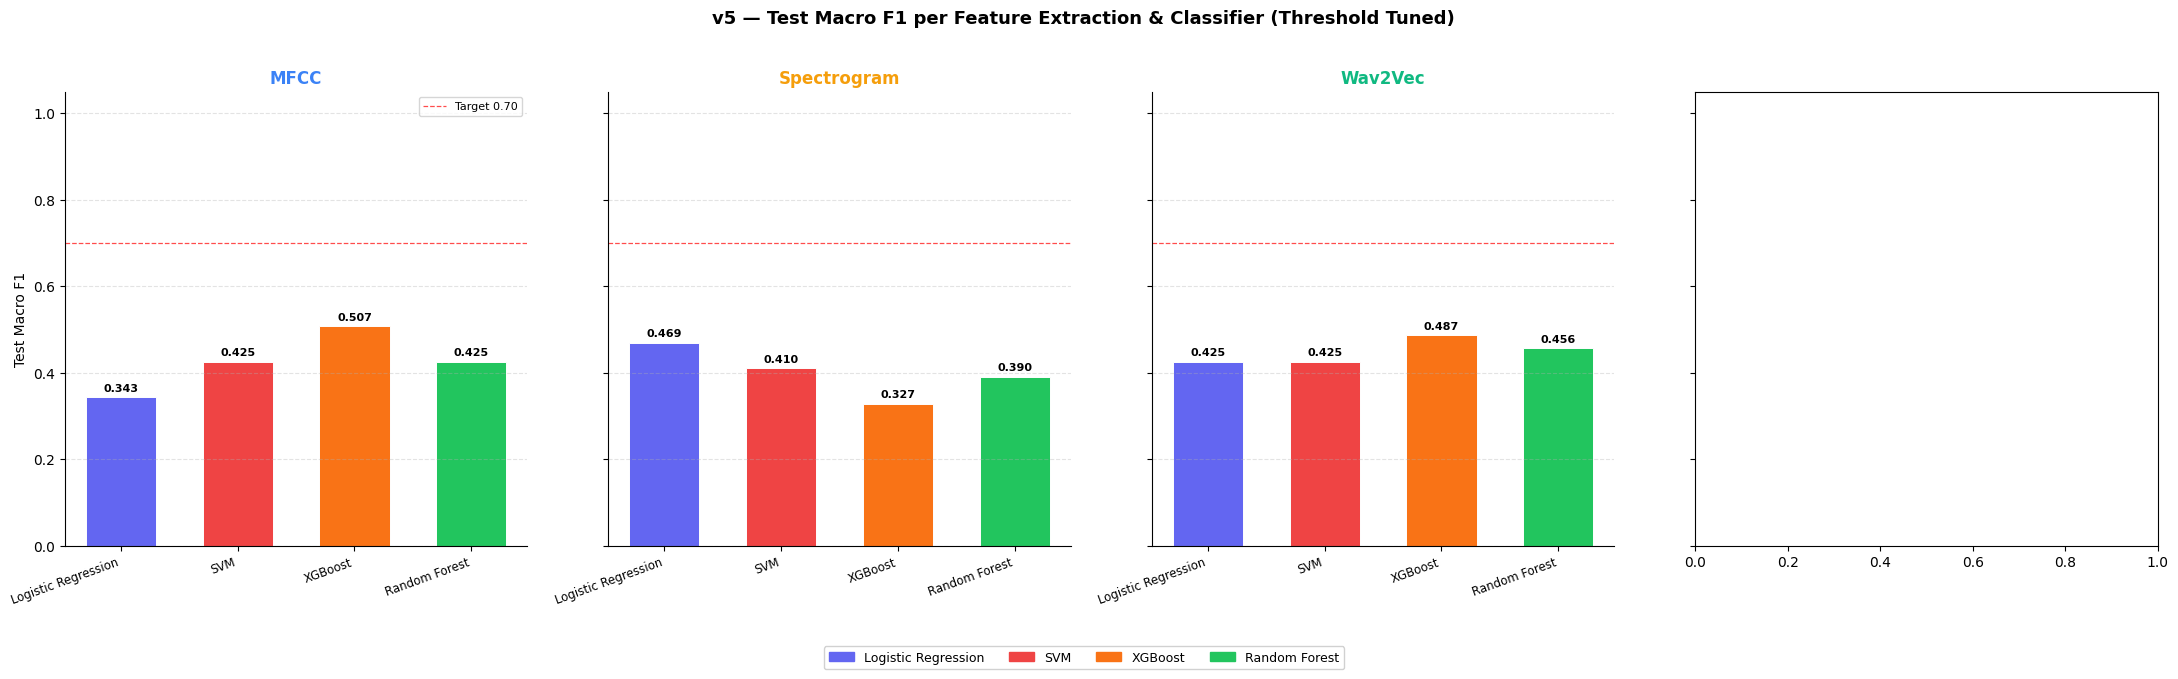

Plot disimpan: d:\repositories\menthealth-ai\results\v5\plots\v5_grouped_bar_f1.png


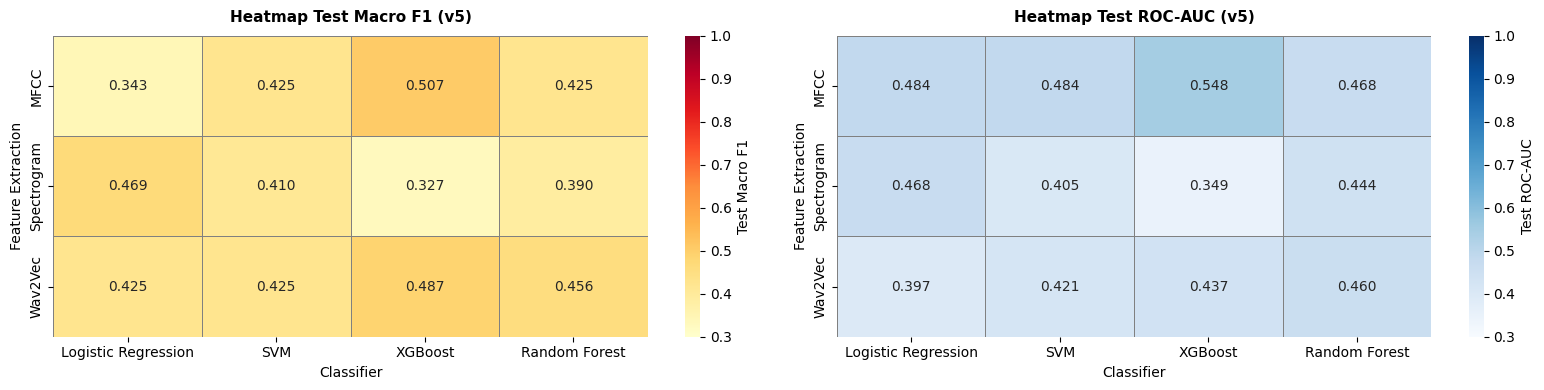

Heatmap disimpan: d:\repositories\menthealth-ai\results\v5\plots\v5_heatmap.png


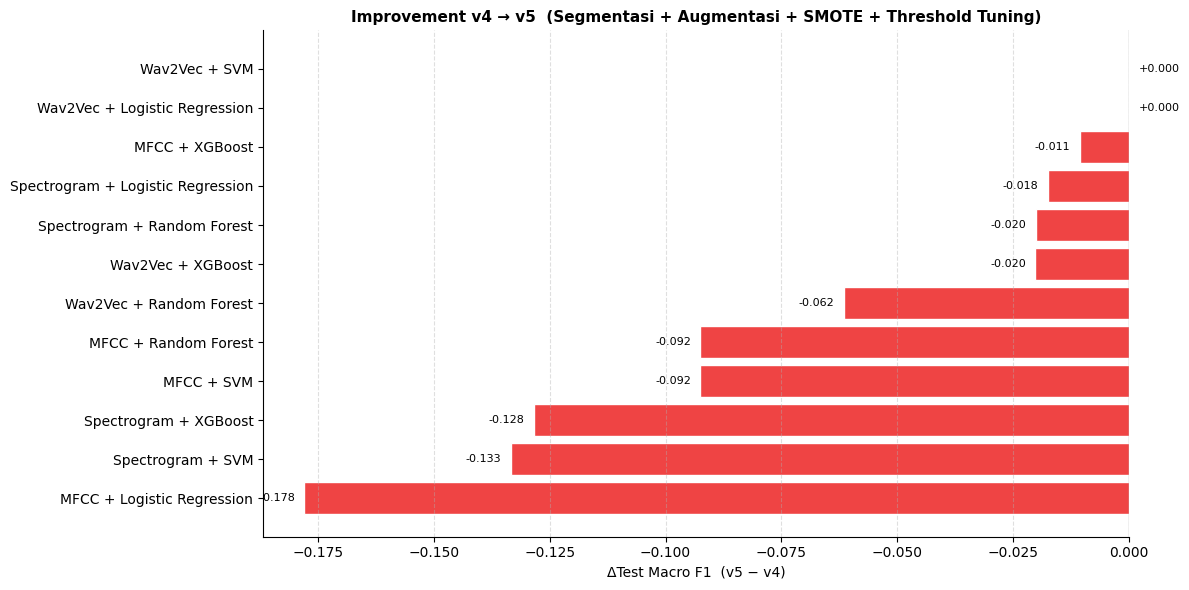

Improvement plot disimpan: d:\repositories\menthealth-ai\results\v5\plots\v5_vs_v4_improvement.png


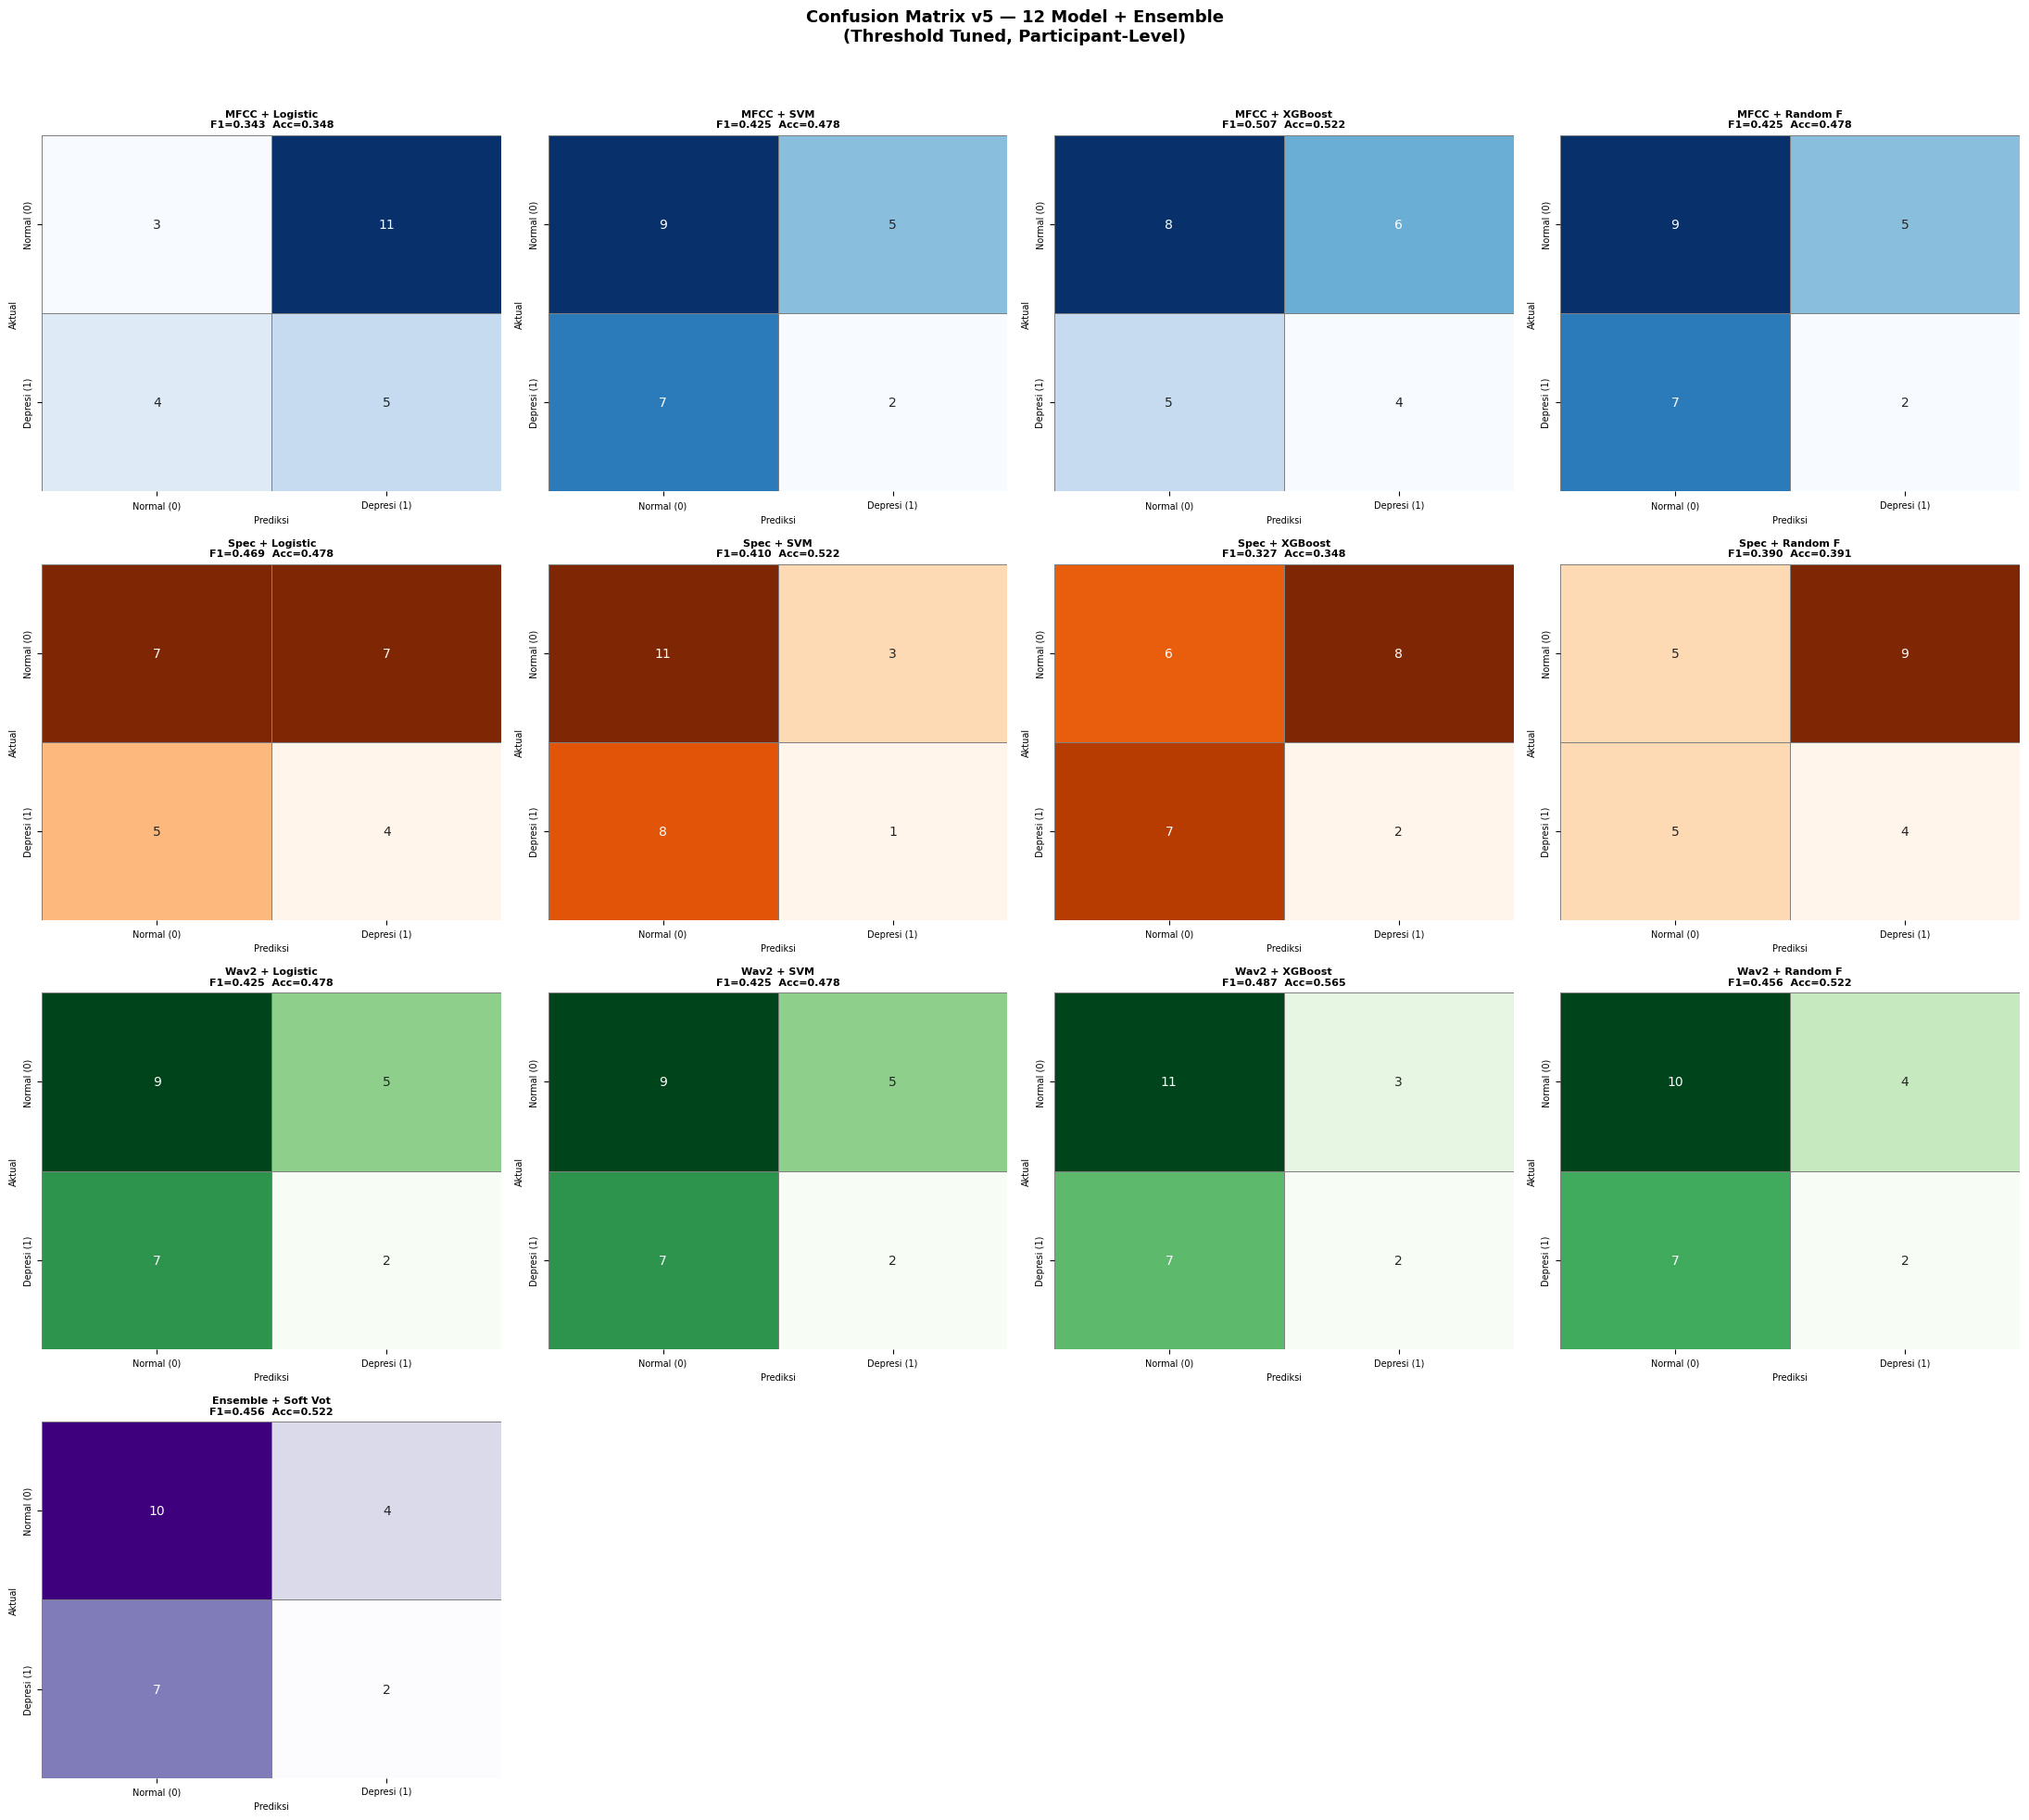

Confusion matrices disimpan: d:\repositories\menthealth-ai\results\v5\confusion_matrix\v5_all_confusion_matrices.png


In [27]:
COLORS_FEAT  = {'MFCC': '#3b82f6', 'Spectrogram': '#f59e0b', 'Wav2Vec': '#10b981', 'Ensemble': '#8b5cf6'}
COLORS_MODEL = ['#6366f1', '#ef4444', '#f97316', '#22c55e', '#8b5cf6']

# ─── 10A. Grouped Bar: Test Macro F1 per Feature × Model ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)
fig.suptitle('v5 — Test Macro F1 per Feature Extraction & Classifier (Threshold Tuned)',
             fontsize=13, fontweight='bold', y=1.02)

x       = np.arange(len(MODEL_NAMES))
bar_w   = 0.6

for ax_idx, feat_name in enumerate(FEAT_NAMES):
    ax = axes[ax_idx]
    vals = [all_results[f"{feat_name} + {mn}"]['test_f1_macro'] for mn in MODEL_NAMES]
    bars = ax.bar(x, vals, width=bar_w, color=COLORS_MODEL[:len(MODEL_NAMES)],
                  edgecolor='white', linewidth=0.7)
    ax.set_title(feat_name, fontweight='bold', fontsize=12, color=COLORS_FEAT[feat_name])
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=8.5)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Test Macro F1' if ax_idx == 0 else '')
    ax.axhline(0.7, color='red', linestyle='--', linewidth=0.9, alpha=0.7, label='Target 0.70')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    if ax_idx == 0:
        ax.legend(fontsize=8)

patches = [mpatches.Patch(color=COLORS_MODEL[i], label=MODEL_NAMES[i])
           for i in range(len(MODEL_NAMES))]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.09), framealpha=0.9)

plt.tight_layout()
p = os.path.join(RESULTS_DIR, "plots", "v5_grouped_bar_f1.png")
fig.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot disimpan: {p}")

# ─── 10B. Heatmap F1 & AUC ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, metric, title, cmap in zip(
    axes,
    ['test_f1_macro', 'test_roc_auc'],
    ['Test Macro F1', 'Test ROC-AUC'],
    ['YlOrRd', 'Blues']
):
    data = pd.DataFrame(
        [[all_results[f"{fn} + {mn}"][metric] for mn in MODEL_NAMES] for fn in FEAT_NAMES],
        index=FEAT_NAMES, columns=MODEL_NAMES
    ).astype(float)
    sns.heatmap(data, annot=True, fmt='.3f', cmap=cmap,
                linewidths=0.5, linecolor='gray',
                cbar_kws={'label': title},
                ax=ax, vmin=0.3, vmax=1.0)
    ax.set_title(f'Heatmap {title} (v5)', fontweight='bold', fontsize=11, pad=10)
    ax.set_xlabel('Classifier')
    ax.set_ylabel('Feature Extraction')

plt.tight_layout()
p2 = os.path.join(RESULTS_DIR, "plots", "v5_heatmap.png")
fig.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap disimpan: {p2}")

# ─── 10C. v4 vs v5 Improvement Bar ───────────────────────────────────────
# Muat v4 jika ada
v4_csv = os.path.join(PROJECT_ROOT, "results", "v4", "metrics", "daic_v4_comparison_12models.csv")
if os.path.exists(v4_csv):
    df_v4 = pd.read_csv(v4_csv)
    df_v4['combo'] = df_v4['Feature Extraction'] + ' + ' + df_v4['Model']

    v5_f1_map = {
        f"{res['feature_type']} + {res['model_name']}": res['test_f1_macro']
        for res in all_results.values()
        if res['feature_type'] != 'Ensemble'
    }
    df_v4['v5_f1'] = df_v4['combo'].map(v5_f1_map)
    df_v4 = df_v4.dropna(subset=['v5_f1', 'Test Macro F1'])
    df_v4['delta'] = df_v4['v5_f1'] - df_v4['Test Macro F1']
    df_v4 = df_v4.sort_values('delta', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6))
    bar_cols = ['#22c55e' if d >= 0 else '#ef4444' for d in df_v4['delta']]
    ax.barh(df_v4['combo'], df_v4['delta'], color=bar_cols, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('ΔTest Macro F1  (v5 − v4)')
    ax.set_title('Improvement v4 → v5  (Segmentasi + Augmentasi + SMOTE + Threshold Tuning)',
                 fontweight='bold', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, (_, row) in enumerate(df_v4.iterrows()):
        ax.text(row['delta'] + 0.002 if row['delta'] >= 0 else row['delta'] - 0.002,
                i, f"{row['delta']:+.3f}", va='center',
                ha='left' if row['delta'] >= 0 else 'right', fontsize=8)
    plt.tight_layout()
    p3 = os.path.join(RESULTS_DIR, "plots", "v5_vs_v4_improvement.png")
    fig.savefig(p3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Improvement plot disimpan: {p3}")

# ─── 10D. Confusion Matrix — 12 Model + Ensemble ──────────────────────────
CMAPS = {'MFCC': 'Blues', 'Spectrogram': 'Oranges', 'Wav2Vec': 'Greens', 'Ensemble': 'Purples'}
class_labels = ['Normal (0)', 'Depresi (1)']

fig, axes = plt.subplots(4, 4, figsize=(22, 20))
fig.suptitle('Confusion Matrix v5 — 12 Model + Ensemble\n(Threshold Tuned, Participant-Level)',
             fontsize=13, fontweight='bold')

all_combos = [(fn, mn) for fn in FEAT_NAMES for mn in MODEL_NAMES] + [('Ensemble', 'Soft Voting (12)')]

for idx, (fn, mn) in enumerate(all_combos):
    ax      = axes[idx // 4, idx % 4]
    combo_k = f"ENSEMBLE (All 12)" if fn == 'Ensemble' else f"{fn} + {mn}"
    if combo_k not in all_y_te:
        ax.axis('off')
        continue
    y_true, y_pred = all_y_te[combo_k]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    f1  = all_results[combo_k]['test_f1_macro']
    acc = all_results[combo_k]['test_accuracy']
    sns.heatmap(cm, annot=True, fmt='d',
                cmap=CMAPS.get(fn, 'Blues'), ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, linecolor='gray', cbar=False)
    short_fn = fn if fn == 'Ensemble' else fn[:4]
    ax.set_title(f'{short_fn} + {mn[:8]}\nF1={f1:.3f}  Acc={acc:.3f}',
                 fontweight='bold', fontsize=8)
    ax.set_xlabel('Prediksi', fontsize=7)
    ax.set_ylabel('Aktual', fontsize=7)
    ax.tick_params(labelsize=7)

# Matikan subplot kosong
for idx in range(len(all_combos), 16):
    axes[idx // 4, idx % 4].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
p4 = os.path.join(RESULTS_DIR, "confusion_matrix", "v5_all_confusion_matrices.png")
fig.savefig(p4, dpi=150, bbox_inches='tight')
plt.show()
print(f"Confusion matrices disimpan: {p4}")


11. Classification Report Lengkap


In [28]:
print("\n" + "=" * 100)
print(f"{'CLASSIFICATION REPORT LENGKAP — v5 (12 Model + Ensemble)':^100}")
print("=" * 100)

for fn in FEAT_NAMES:
    print(f"\n{'─'*100}\n  FEATURE: {fn}\n{'─'*100}")
    for mn in MODEL_NAMES:
        combo_k = f"{fn} + {mn}"
        y_true, y_pred = all_y_te[combo_k]
        thr = all_results[combo_k]['best_threshold']
        print(f"\n  [{mn}]  (threshold={thr:.3f})")
        print(classification_report(y_true, y_pred, labels=[0, 1],
                                    target_names=class_labels, zero_division=0))

print(f"\n{'─'*100}\n  ENSEMBLE (Soft Voting — 12 Model)\n{'─'*100}")
y_true_e, y_pred_e = all_y_te['ENSEMBLE (All 12)']
print(classification_report(y_true_e, y_pred_e, labels=[0, 1],
                             target_names=class_labels, zero_division=0))

print("\n[OK] Pipeline Traditional ML v5 selesai!")
print(f"     Models dir  : {MODELS_DIR}")
print(f"     Results dir : {RESULTS_DIR}")



                      CLASSIFICATION REPORT LENGKAP — v5 (12 Model + Ensemble)                      

────────────────────────────────────────────────────────────────────────────────────────────────────
  FEATURE: MFCC
────────────────────────────────────────────────────────────────────────────────────────────────────

  [Logistic Regression]  (threshold=0.250)
              precision    recall  f1-score   support

  Normal (0)       0.43      0.21      0.29        14
 Depresi (1)       0.31      0.56      0.40         9

    accuracy                           0.35        23
   macro avg       0.37      0.38      0.34        23
weighted avg       0.38      0.35      0.33        23


  [SVM]  (threshold=0.625)
              precision    recall  f1-score   support

  Normal (0)       0.56      0.64      0.60        14
 Depresi (1)       0.29      0.22      0.25         9

    accuracy                           0.48        23
   macro avg       0.42      0.43      0.43        23
weighted